## 1. Setup & Imports
All third-party imports, device selection, and global random seed.

In [1]:
import os, math, random
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.10.0+cu128


## 2. Configuration
All hyperparameters and paths in one place — change here only.

In [2]:
cfg = SimpleNamespace(
    # --- Paths ---
    dataset_dir="/kaggle/input/competitions/csiro-biomass",
    dino_weights_dir="/kaggle/input/datasets/darealvictorslorer/dinov2-small-weights/dinov2-small",
    output_dir="/kaggle/working",
    # --- Model ---
    input_dim=384,
    latent_dim=64,
    output_dim=5,
    dropout=0.3,
    # --- CEMS ---
    sigma=1e-3,        # tangent perturbation std (paper default)
    cems_method=1,     # batch-centred SVD
    initial_d=5,       # intrinsic dimension estimate (from local Part-2 run: d≈4.71)
    use_hessian=False, # False → CEMS-L (first-order/linear); True → full CEMS
    # --- Augmentation ---
    # Subset of ["identity", "hflip", "vflip", "hflip_vflip"]; must include "identity"
    augmentations=["identity", "hflip_vflip"],
    # --- Training ---
    epochs=80,         # total epoch budget across both phases
    lr=3e-4,
    weight_decay=1e-3,
    seed=42,
    # --- Two-stage training ---
    batch_size=64,     # mini-batch size for both phases
    phase_1_cap=30,    # hard epoch cap for phase 1 (triggers phase 2 even if d is still rising)
    patience_k=5,      # epochs of non-improving d before phase transition
    lambda_aug=1.0,    # CEMS loss weight in phase 2
    # --- Split ---
    n_splits=5,
    val_fold=0,
)

TARGETS = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]
WEIGHTS = {"Dry_Green_g": 0.1, "Dry_Dead_g": 0.1, "Dry_Clover_g": 0.1,
           "GDM_g": 0.2, "Dry_Total_g": 0.5}

TRAIN_CSV    = os.path.join(cfg.dataset_dir, "train.csv")
TEST_CSV     = os.path.join(cfg.dataset_dir, "test.csv")
TRAIN_IMG_DIR = os.path.join(cfg.dataset_dir, "train")
TEST_IMG_DIR  = os.path.join(cfg.dataset_dir, "test")

print("train.csv:",  os.path.exists(TRAIN_CSV))
print("test.csv:",   os.path.exists(TEST_CSV))
print("train dir:",  os.path.exists(TRAIN_IMG_DIR))
print("test dir:",   os.path.exists(TEST_IMG_DIR))
print("dino dir:",   os.path.exists(cfg.dino_weights_dir))

train.csv: True
test.csv: True
train dir: True
test dir: True
dino dir: True


## 3. Load DINOv2
Load ViT-S/14 from uploaded HuggingFace weights; smoke-test at 504×252 resolution.

In [3]:
print(f"Loading DINOv2-small from {cfg.dino_weights_dir} ...")
dino = AutoModel.from_pretrained(cfg.dino_weights_dir).eval().to(device)
for p in dino.parameters():
    p.requires_grad_(False)

# Smoke test: 504x252 input (W=504, H=252) — must pass interpolate_pos_encoding=True
# because this is a non-standard resolution for the HF wrapper.
_dummy = torch.zeros(1, 3, 252, 504, device=device)  # (B, C, H, W)
with torch.no_grad():
    _out = dino(pixel_values=_dummy, interpolate_pos_encoding=True)
    _cls = _out.last_hidden_state[:, 0, :]  # CLS token
assert _cls.shape == (1, 384), f"Expected (1, 384), got {_cls.shape}"
print(f"DINOv2 smoke test passed — CLS shape: {_cls.shape}")
del _dummy, _out, _cls

Loading DINOv2 ViT-S/14 from /kaggle/input/datasets/darealvictorslorer/dinov2-small-weights/dinov2-small ...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 smoke test passed — CLS shape: torch.Size([1, 384])


## 4. Load Training CSV
Pivot long-format CSV to wide format (one row per image) and extract Y matrix.

In [4]:
df_raw = pd.read_csv(TRAIN_CSV)
df_raw["image_id"] = df_raw["sample_id"].str.split("__").str[0]

df_wide = df_raw.pivot_table(
    index=["image_id", "image_path"],
    columns="target_name",
    values="target",
).reset_index()

Y_all = df_wide[TARGETS].values.astype(np.float32)  # (N, 5)
train_image_ids_all = df_wide["image_id"].values

print(f"Training images: {len(df_wide)}")
print(f"Y_all shape:     {Y_all.shape}")
print(df_wide.head(3))

Training images: 357
Y_all shape:     (357, 5)
target_name      image_id              image_path  Dry_Clover_g  Dry_Dead_g  \
0            ID1011485656  train/ID1011485656.jpg          0.00     31.9984   
1            ID1012260530  train/ID1012260530.jpg          0.00      0.0000   
2            ID1025234388  train/ID1025234388.jpg          6.05      0.0000   

target_name  Dry_Green_g  Dry_Total_g   GDM_g  
0                16.2751      48.2735  16.275  
1                 7.6000       7.6000   7.600  
2                 0.0000       6.0500   6.050  


## 5. Extract DINOv2 Features — Training Images
Preprocess at 504×252 and extract CLS tokens with configurable augmentations (identity, hflip, vflip, hflip+vflip).

In [5]:
# 504x252 = (W x H); torchvision Resize takes (H, W) = (252, 504)
# Matches extract_features.py: DINOV2_RESIZE=(504,252), Resize((252,504))
_dino_transform = T.Compose([
    T.Resize((252, 504)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def extract_features(image_paths, model, transform):
    """Return (N, 384) float32 array of CLS-token features."""
    feats = []
    for i, p in enumerate(image_paths):
        img = Image.open(p).convert("RGB")
        x = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(pixel_values=x, interpolate_pos_encoding=True)
            feat = out.last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()
        feats.append(feat)
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(image_paths)}")
    return np.stack(feats).astype(np.float32)


_AUGMENTATION_FNS = {
    "identity":    lambda img: img,
    "hflip":       lambda img: TF.hflip(img),
    "vflip":       lambda img: TF.vflip(img),
    "hflip_vflip": lambda img: TF.hflip(TF.vflip(img)),
}
_ORIENTATIONS = [_AUGMENTATION_FNS[a] for a in cfg.augmentations]
n_aug = len(_ORIENTATIONS)


def extract_features_augmented(image_paths, model, transform):
    """Return (N*n_aug, 384) array — each image appears n_aug times."""
    feats = []
    for i, p in enumerate(image_paths):
        img = Image.open(p).convert("RGB")
        for flip_fn in _ORIENTATIONS:
            x = transform(flip_fn(img)).unsqueeze(0).to(device)
            with torch.no_grad():
                out = model(pixel_values=x, interpolate_pos_encoding=True)
                feat = out.last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()
            feats.append(feat)
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(image_paths)}")
    return np.stack(feats).astype(np.float32)


train_image_paths = [
    os.path.join(TRAIN_IMG_DIR, f"{iid}.jpg")
    for iid in train_image_ids_all
]
N_orig = len(train_image_paths)
print(f"Extracting features for {N_orig} training images ({n_aug} orientations each)...")
X_all = extract_features_augmented(train_image_paths, dino, _dino_transform)

# Expand Y and image IDs to match augmented feature array
Y_all               = np.repeat(Y_all,               n_aug, axis=0)
train_image_ids_all = np.repeat(train_image_ids_all, n_aug)
image_group_ids     = np.repeat(np.arange(N_orig),   n_aug)

print(f"X_all shape:         {X_all.shape}")
print(f"Y_all shape:         {Y_all.shape}")
print(f"image_group_ids len: {len(image_group_ids)}")
print(f"Unique groups:       {len(np.unique(image_group_ids))}")

# Sanity checks
assert X_all.shape == (N_orig * n_aug, 384), f"Expected ({N_orig*n_aug}, 384), got {X_all.shape}"
assert Y_all.shape == (N_orig * n_aug, 5)
assert len(image_group_ids) == N_orig * n_aug
assert len(np.unique(image_group_ids)) == N_orig
assert np.all(np.bincount(image_group_ids) == n_aug), "Each group must appear exactly n_aug times"
print("Sanity checks passed.")

Extracting features for 357 training images (2 orientations each)...
  50/357
  100/357
  150/357
  200/357
  250/357
  300/357
  350/357
X_all shape:         (714, 384)
Y_all shape:         (714, 5)
image_group_ids len: 714
Unique groups:       357
Sanity checks passed.


## 6. Extract DINOv2 Features — Test Images
Same preprocessing pipeline applied to the held-out test set.

In [6]:
df_test_raw = pd.read_csv(TEST_CSV)
df_test_raw["image_id"] = df_test_raw["sample_id"].str.split("__").str[0]
df_test_unique = df_test_raw.drop_duplicates("image_id").copy()

test_image_ids = df_test_unique["image_id"].values
test_image_paths = [
    os.path.join(TEST_IMG_DIR, f"{iid}.jpg")
    for iid in test_image_ids
]

print(f"Extracting features for {len(test_image_paths)} test images...")
X_test = extract_features(test_image_paths, dino, _dino_transform)
print(f"X_test shape: {X_test.shape}")

Extracting features for 1 test images...
X_test shape: (1, 384)


## 7. GroupKFold Train/Val Split
Fold 0 of a 5-fold GroupKFold; groups on image_path (one unique group per image).

In [7]:
gkf = GroupKFold(n_splits=cfg.n_splits)
# Group by original image index so all 4 orientations of an image land in the
# same fold — prevents leakage (original in train, hflip in val = cheating).
splits = list(gkf.split(X_all, groups=image_group_ids))
train_idx, val_idx = splits[cfg.val_fold]

X_train     = X_all[train_idx]
Y_train_raw = Y_all[train_idx]
X_val       = X_all[val_idx]
Y_val_raw   = Y_all[val_idx]
train_ids_split = train_image_ids_all[train_idx]
val_ids_split   = train_image_ids_all[val_idx]

# Sanity check: no original image shared across train and val
train_groups = set(image_group_ids[train_idx].tolist())
val_groups   = set(image_group_ids[val_idx].tolist())
assert train_groups.isdisjoint(val_groups), "Group leakage: original images shared across folds!"
print("Group overlap check: PASSED (zero overlap)")

print(f"Train: {X_train.shape}  Val: {X_val.shape}")
print(f"Y_train range: [{Y_train_raw.min():.1f}, {Y_train_raw.max():.1f}]")

Group overlap check: PASSED (zero overlap)
Train: (570, 384)  Val: (144, 384)
Y_train range: [0.0, 185.7]


## 8. MinMaxScaler on Y_train
Fit scaler on training labels only; used inside CEMS joint space for label normalisation.

In [8]:
y_scaler = MinMaxScaler()
y_scaler.fit(Y_train_raw)
Y_train_scaled = y_scaler.transform(Y_train_raw).astype(np.float32)

print(f"Y_train_scaled range: [{Y_train_scaled.min():.3f}, {Y_train_scaled.max():.3f}]")
print("Scaler data_min_:", y_scaler.data_min_.round(2))
print("Scaler data_max_:", y_scaler.data_max_.round(2))

Y_train_scaled range: [0.000, 1.000]
Scaler data_min_: [0.   0.   0.   1.4  2.48]
Scaler data_max_: [157.98  83.84  71.79 157.98 185.7 ]


## 9. Model Architecture — Encoder, Head, BiomassModel
Encoder 384→256→64 (GELU, Dropout), Head 64→32→5 (GELU, no dropout).
The fresh phase-2 head is instantiated as a plain `nn.Sequential` without dropout — CEMS is the regularizer.

In [9]:
class Encoder(nn.Module):
    """384 → 256 → 64 (GELU, Dropout)."""

    def __init__(self, input_dim=384, latent_dim=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, latent_dim),
        )

    def forward(self, x):
        return self.net(x)


class Head(nn.Module):
    """64 → 32 → 5 (GELU, Dropout)."""

    def __init__(self, latent_dim=64, output_dim=5, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, output_dim),
        )

    def forward(self, z):
        return self.net(z)


class BiomassModel(nn.Module):

    def __init__(self, input_dim=384, latent_dim=64, output_dim=5, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(input_dim, latent_dim, dropout)
        self.head = Head(latent_dim, output_dim, dropout)

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        return self.head(self.encode(x))

    def forward_cems(self, args, x, y_scaled):
        """CEMS augmentation path.

        Encodes x, detaches latent so SVD/ridge don't backprop through encoder,
        then runs get_batch_cems in 64-d latent space.
        Returns (pred_aug, y_aug_scaled).
        """
        latent = self.encode(x)
        latent_aug, y_aug_scaled = get_batch_cems(
            args, latent.detach(), y_scaled, latent=True,
        )
        return self.head(latent_aug), y_aug_scaled


print("BiomassModel defined.")
# Quick parameter count
_tmp = BiomassModel(cfg.input_dim, cfg.latent_dim, cfg.output_dim, cfg.dropout)
n_params = sum(p.numel() for p in _tmp.parameters())
print(f"Parameters: {n_params:,}")
del _tmp

BiomassModel defined.
Parameters: 117,253


## 10. CEMS Algorithm
Port of cems.py: _adjust_dims, _get_projection, _estimate_grad_hessian, _sample_tangent, get_batch_cems.

In [10]:
# ---------------------------------------------------------------------------
# Per-batch intrinsic dimension estimate (TwoNN, lightweight)
# ---------------------------------------------------------------------------

def _twonn_batch(zi):
    """TwoNN ID estimate on a small batch (b, m). Returns rounded int."""
    with torch.no_grad():
        dists = torch.cdist(zi.float(), zi.float())
        dists.fill_diagonal_(float('inf'))
        top2 = dists.topk(2, dim=1, largest=False).values
        r1, r2 = top2[:, 0], top2[:, 1]
        mask = r1 > 0
        if mask.sum() < 3:
            return 2
        mu = (r2 / r1)[mask]
        mu_sorted, _ = mu.sort()
        n = len(mu_sorted)
        ecdf = torch.arange(1, n + 1, dtype=torch.float32, device=zi.device) / n
        log_mu   = torch.log(mu_sorted)
        log_surv = -torch.log1p(-ecdf + 1e-10)
        denom = (log_mu * log_mu).sum()
        if denom.abs() < 1e-12:
            return 2
        d = float((log_mu * log_surv).sum() / denom)
    if not math.isfinite(d) or d < 1:
        return 2
    return max(1, int(round(d)))


# ---------------------------------------------------------------------------
# Step 1 — flatten + form joint space zi = [x | y]
# ---------------------------------------------------------------------------

def _adjust_dims(x, y, xk=None, yk=None):
    if x.ndim > 2:
        x = x.reshape(x.shape[0], -1)
    if y.ndim == 1:
        y = y.reshape(y.shape[0], 1)
    m  = x.shape[-1]
    zi = torch.cat((x, y), dim=-1)
    zk = None
    if xk is not None and yk is not None:
        if xk.ndim > 3:
            xk = xk.reshape(xk.shape[0], xk.shape[1], -1)
        zk = torch.cat((xk, yk), dim=-1)
    return x, zi, zk, m


# ---------------------------------------------------------------------------
# Step 2 — SVD local orthonormal basis
# ---------------------------------------------------------------------------

def _get_projection(args, x, xk):
    x_c = x.transpose(-2, -1)          # (D, b)
    x_c_mean = None

    if args.cems_method == 1:
        x_c_mean = torch.mean(x_c, -1)           # (D,)
        x_c      = x_c - x_c_mean.unsqueeze(-1)  # singly-centred
    else:
        assert xk is not None
        xk_t = xk.transpose(-1, -2)
        x    = x.unsqueeze(-1)
        x_c  = xk_t - x

    svd_input  = (x_c - x_c_mean.unsqueeze(-1) if x_c_mean is not None else x_c)
    svd_kwargs = {"driver": "gesvd"} if svd_input.is_cuda else {}
    basis, _, _ = torch.linalg.svd(svd_input, full_matrices=False, **svd_kwargs)

    u      = basis.transpose(-2, -1) @ x_c  # (K, b)
    u_prev = u.transpose(-2, -1)             # (b, K)

    if args.cems_method == 1:
        u_t  = u.transpose(-1, -2)                        # (b, K)
        u    = (u_t.unsqueeze(1) - u_t).transpose(-1, -2) # (b, K, b)
        n    = x.shape[0]
        mask = ~torch.eye(n, dtype=torch.bool, device=x.device)
        u    = -u.transpose(-1, -2)[mask].reshape(
            (u.shape[0], u.shape[2] - 1, u.shape[1])
        ).transpose(-1, -2)  # (b, K, b-1)
    elif args.cems_method == 2:
        u = u.unsqueeze(0)

    return basis, u, u_prev, x_c_mean


# ---------------------------------------------------------------------------
# Ridge regression solver
# ---------------------------------------------------------------------------

def _solve_ridge(a, b, lam=1.0):
    n   = a.shape[-1]
    eye = torch.eye(n, device=a.device, dtype=a.dtype)
    a_t = a.transpose(-2, -1)
    return torch.linalg.inv(a_t @ a + lam * eye) @ a_t @ b


# ---------------------------------------------------------------------------
# Steps 3-4 — local gradient and Hessian via ridge regression
# ---------------------------------------------------------------------------

def _estimate_grad_hessian(args, x, xk, d):
    tidx      = torch.triu_indices(d, d, device=x.device)
    ones_mult = torch.ones((d, d), device=x.device)
    ones_mult.fill_diagonal_(0.5)

    basis, u, u_prev, x_mean = _get_projection(args, x, xk)

    u_d = u[:, :d]                          # (b, d, b-1)
    f   = u[:, d:].transpose(-2, -1)        # (b, b-1, n_normal)

    if args.use_hessian:
        uu = torch.einsum(
            'bki,bkj->bkij',
            u_d.transpose(-2, -1),
            u_d.transpose(-2, -1),
        )
        uu   = uu * ones_mult
        uu   = uu[:, :, tidx[0], tidx[1]].transpose(-2, -1)
        psi  = torch.cat((u_d, uu), dim=1).transpose(-2, -1)
    else:
        psi = u_d.transpose(-2, -1)  # CEMS-L: linear only

    lam    = torch.linalg.norm(psi, dim=(-1, -2)).mean()
    b_coef = _solve_ridge(psi, f, lam=lam).transpose(-2, -1)  # (b, n_normal, d or d+n_quad)

    gradient = b_coef[..., :d]
    hessian  = torch.zeros(
        (u.shape[0], b_coef.shape[1], d, d), dtype=b_coef.dtype, device=b_coef.device
    )
    if args.use_hessian:
        hessian[..., tidx[0], tidx[1]] = b_coef[..., d:]
        hessian[..., tidx[1], tidx[0]] = b_coef[..., d:]

    return basis, gradient, hessian, u_d, u_prev, x_mean


# ---------------------------------------------------------------------------
# Step 5 — sample in tangent bundle, project back to ambient space
# ---------------------------------------------------------------------------

def _sample_tangent(args, x, u_k_d, u_prev, x_mean, basis, grad, hess):
    d  = grad.shape[-1]
    nu = torch.distributions.Normal(0, args.sigma).sample(
        (x.shape[0], d, 1)
    ).to(x.device)

    f_nu = (grad @ nu).squeeze(-1)

    if args.use_hessian:
        nu_ex = nu.unsqueeze(1)
        f_nu  = f_nu + 0.5 * (nu_ex.transpose(-1, -2) @ hess @ nu_ex).squeeze((-1, -2))

    x_new_local = torch.cat((nu.squeeze(-1), f_nu), dim=-1)

    if args.cems_method == 1:
        x_new_local = x_new_local + u_prev

    x_cems = (basis @ x_new_local.unsqueeze(-1)).squeeze(-1)
    x_cems = x_cems + (x_mean if args.cems_method == 1 else x)
    return x_cems


# ---------------------------------------------------------------------------
# Public entry — get_batch_cems
# ---------------------------------------------------------------------------

def get_batch_cems(args, x, y, xk=None, yk=None, *, latent=True):
    """CEMS augmentation for one minibatch. Returns (x_new, y_new)."""
    x_shape, y_shape = x.shape, y.shape
    x_flat, zi, zk, m = _adjust_dims(x, y, xk, yk)

    d = args.id
    if latent:
        with torch.no_grad():
            d = _twonn_batch(zi)

    d = min(d, zi.shape[-1] - 1, zi.shape[-2] - 1)
    d = max(d, 1)

    basis, grad, hess, u_k_d, u_prev, x_mean = _estimate_grad_hessian(args, zi, zk, d)
    z_sampled = _sample_tangent(args, zi, u_k_d, u_prev, x_mean, basis, grad, hess)

    x_new = z_sampled[..., :m].reshape(x_shape)
    y_new = z_sampled[..., m:].reshape(y_shape)
    return x_new, y_new


print("CEMS functions defined.")

CEMS functions defined.


## 11. Neighbourhood Utilities & TwoNN
precompute_knn for anchor-based CEMS; in-house TwoNN for global ID estimation.

> **Note — augmented twins as neighbours:** With 2× flip augmentation (identity + hflip_vflip), `precompute_knn` operates on a N_train×latent_dim matrix. The 2 orientations of any given image are genuinely close in feature space and share identical Y values, so they frequently end up as each other's nearest neighbours. This is intentional and correct — they are valid CEMS neighbourhood members.

In [11]:
def _next_power_of_2(n):
    if n < 1:
        return 1
    return 1 << (n - 1).bit_length()


def compute_neigh_size(d):
    """neigh_size = next_power_of_2(d + d*(d+1)/2 + 1)."""
    base = d + d * (d + 1) // 2
    return _next_power_of_2(base + 1)


def precompute_knn(X, Y, neigh_size, compute_device="cpu"):
    """Pre-sort training points by Euclidean distance in joint [X, Y] space.

    Returns int64 array (N, neigh_size); col 0 = self-index.
    """
    XY = np.concatenate([X, Y], axis=1).astype(np.float32)
    t  = torch.tensor(XY, dtype=torch.float32)
    if compute_device in ("cuda", "mps"):
        try:
            t = t.to(compute_device)
        except Exception:
            pass  # fall back to CPU silently

    dists = torch.cdist(t, t, p=2, compute_mode="donot_use_mm_for_euclid_dist")
    dists.fill_diagonal_(-float('inf'))  # self sorts to col 0
    sorted_idx = torch.argsort(dists, dim=1).cpu().numpy()
    return sorted_idx[:, :neigh_size].astype(np.int64)


def twonn_inhouse(X):
    """In-house TwoNN (Facco et al. 2017). Returns float ID estimate."""
    nn_model = NearestNeighbors(n_neighbors=3, algorithm="auto", metric="euclidean")
    nn_model.fit(X)
    dists, _ = nn_model.kneighbors(X)
    r1, r2  = dists[:, 1], dists[:, 2]  # col 0 is self
    mask    = r1 > 0
    r1, r2  = r1[mask], r2[mask]
    mu      = r2 / r1
    mu_s    = np.sort(mu)
    n       = len(mu_s)
    ecdf    = np.arange(1, n + 1) / n
    log_mu  = np.log(mu_s)
    log_surv = -np.log1p(-ecdf + 1e-10)
    return float(np.dot(log_mu, log_surv) / np.dot(log_mu, log_mu))


print("Neighbourhood utilities defined.")

Neighbourhood utilities defined.


## 12. Loss, Metrics & Dataset
Weighted SmoothL1, weighted global R², per-target RMSE, and a minimal PyTorch Dataset.

In [12]:
WEIGHT_VECTOR = np.array([WEIGHTS[t] for t in TARGETS], dtype=np.float64)
_LOSS_WEIGHTS = torch.tensor(WEIGHT_VECTOR, dtype=torch.float32)


def _weighted_smooth_l1(pred, target, weights, beta=1.0):
    """Per-target weighted SmoothL1, averaged over the batch."""
    loss_per = nn.functional.smooth_l1_loss(pred, target, beta=beta, reduction="none")
    return (loss_per * weights.to(pred.device)).mean()


def weighted_global_r2(y_true, y_pred):
    """Kaggle competition metric: weighted global R² across all (image, target) pairs."""
    w  = WEIGHT_VECTOR
    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)
    ww = np.repeat(w, y_true.shape[0])
    ybar   = np.sum(ww * yt) / np.sum(ww)
    ss_res = np.sum(ww * (yt - yp) ** 2)
    ss_tot = np.sum(ww * (yt - ybar) ** 2) + 1e-12
    return float(1.0 - ss_res / ss_tot)


def rmse_per_target(y_true, y_pred):
    return {t: float(np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])))
            for i, t in enumerate(TARGETS)}


class BiomassDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


@torch.no_grad()
def eval_epoch(model, loader, eval_device):
    model.eval()
    total_loss, all_pred, all_true = 0.0, [], []
    for X, y in loader:
        X, y = X.to(eval_device), y.to(eval_device)
        pred = model(X)
        total_loss += _weighted_smooth_l1(pred, y, _LOSS_WEIGHTS).item() * len(X)
        all_pred.append(pred.cpu().numpy())
        all_true.append(y.cpu().numpy())
    y_pred = np.concatenate(all_pred)
    y_true = np.concatenate(all_true)
    r2   = weighted_global_r2(y_true, y_pred)
    rmse = rmse_per_target(y_true, y_pred)
    return total_loss / len(loader.dataset), r2, rmse, y_pred, y_true


print("Loss, metrics, dataset, eval_epoch defined.")

Loss, metrics, dataset, eval_epoch defined.


## 13. Two-Stage Training
**Phase 1 — Encoder ERM:** Mini-batch AdamW over the full model, `ceil(N_train / batch_size)` optimizer steps per epoch. Encoder checkpointed whenever latent d improves. Phase transitions after `patience_k` epochs of non-improving d (or at `phase_1_cap`).

**Phase transition:** Load best encoder state, freeze encoder (requires_grad=False + eval()), cache frozen latents once, build kNN on joint [latents, Y_scaled], reinitialise head (no dropout) and optimizer over remaining epoch budget.

**Phase 2 — Head CEMS:** Same step count per epoch. For each batch of B anchors, fetch each anchor's kNN neighbourhood, run CEMS to produce (z_new, y_new) augmented pairs for the whole neighbourhood, forward real + augmented latents through head, one loss.backward() + optimizer.step() per batch. Latent d is constant across phase 2 (encoder frozen) — drift would indicate a gradient leak.

In [13]:
# ── Two-stage config ───────────────────────────────────────
BATCH_SIZE   = cfg.batch_size
PHASE_1_CAP  = cfg.phase_1_cap
PATIENCE_K   = cfg.patience_k
LAMBDA_AUG   = cfg.lambda_aug
TOTAL_EPOCHS = cfg.epochs

# ── Neighbourhood (used by CEMS in phase 2) ───────────────
d_for_neigh = cfg.initial_d
neigh_size  = compute_neigh_size(d_for_neigh)
print(f"d={d_for_neigh}  d+d*(d+1)/2={d_for_neigh + d_for_neigh*(d_for_neigh+1)//2}  neigh_size={neigh_size}")

# ── CEMS args ─────────────────────────────────────────────
cems_args = SimpleNamespace(
    sigma=cfg.sigma,
    cems_method=cfg.cems_method,
    id=d_for_neigh,
    use_hessian=cfg.use_hessian,
)

# ── Val loader (used throughout) ──────────────────────────
val_ds     = BiomassDataset(X_val, Y_val_raw)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)

# ── Device tensors for training set ───────────────────────
X_t     = torch.tensor(X_train,        dtype=torch.float32, device=device)
Y_raw_t = torch.tensor(Y_train_raw,    dtype=torch.float32, device=device)
Y_sc_t  = torch.tensor(Y_train_scaled, dtype=torch.float32, device=device)

N_train         = len(X_train)
steps_per_epoch = math.ceil(N_train / BATCH_SIZE)
print(f"\nN_train={N_train}  batch_size={BATCH_SIZE}  steps/epoch={steps_per_epoch}")
print(f"Total epoch budget={TOTAL_EPOCHS}  phase_1_cap={PHASE_1_CAP}  patience_k={PATIENCE_K}")

# ── Model ─────────────────────────────────────────────────
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
model = BiomassModel(cfg.input_dim, cfg.latent_dim, cfg.output_dim, cfg.dropout).to(device)

# ── Shared history (one entry per epoch, both phases) ─────
history = {k: [] for k in ["train_loss", "val_loss", "val_r2", "val_rmse", "latent_d"]}
phase_transition_epoch = None  # absolute epoch index where phase 2 starts

# ══════════════════════════════════════════════════════════
# PHASE 1 — Encoder ERM training (no CEMS)
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("PHASE 1: Encoder ERM training")
print(f"  steps/epoch = {steps_per_epoch}  "
      f"(must equal ceil({N_train}/{BATCH_SIZE}) = {math.ceil(N_train/BATCH_SIZE)})")
print("=" * 62)

optimizer_p1 = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=TOTAL_EPOCHS, eta_min=cfg.lr / 100
)

best_d              = -float("inf")
best_d_epoch        = 0
best_encoder_state  = None
epochs_since_best_d = 0
phase1_end_epoch    = 0

for epoch in range(1, PHASE_1_CAP + 1):
    model.train()
    perm    = np.random.permutation(N_train)
    ep_loss = 0.0
    n_seen  = 0

    for step in range(steps_per_epoch):
        idx = perm[step * BATCH_SIZE : (step + 1) * BATCH_SIZE]
        X_b = X_t[idx]
        Y_b = Y_raw_t[idx]
        optimizer_p1.zero_grad()
        loss = _weighted_smooth_l1(model(X_b), Y_b, _LOSS_WEIGHTS)
        loss.backward()
        optimizer_p1.step()
        ep_loss += loss.item() * len(idx)
        n_seen  += len(idx)

    scheduler_p1.step()
    tr_loss = ep_loss / n_seen

    # eval_epoch leaves model in eval mode — d is then measured without dropout noise
    val_loss, val_r2, val_rmse, _, _ = eval_epoch(model, val_loader, device)

    with torch.no_grad():
        ep_d = twonn_inhouse(model.encode(X_t).cpu().numpy())

    # Checkpoint encoder on best d (save encoder.state_dict only; head is discarded)
    if ep_d > best_d:
        best_d             = ep_d
        best_d_epoch       = epoch
        best_encoder_state = {k: v.cpu().clone() for k, v in model.encoder.state_dict().items()}
        epochs_since_best_d = 0
    else:
        epochs_since_best_d += 1

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_r2"].append(val_r2)
    history["val_rmse"].append(val_rmse)
    history["latent_d"].append(ep_d)

    rmse_str = "  ".join(f"{t.split('_')[1]}:{v:.2f}" for t, v in val_rmse.items())
    print(
        f"  P1 ep {epoch:3d}  loss={tr_loss:.4f}  val_R²={val_r2:.4f}  d={ep_d:.2f}  "
        f"best_d={best_d:.2f}@ep{best_d_epoch}  patience={epochs_since_best_d}/{PATIENCE_K}  "
        f"[{rmse_str}]"
    )

    phase1_end_epoch = epoch

    if epochs_since_best_d >= PATIENCE_K:
        print(f"\n  Patience reached at epoch {epoch}. Triggering phase 2.")
        break
else:
    # Loop completed without break — hit hard cap
    print(
        f"\n  WARNING: Phase 1 hit hard cap ({PHASE_1_CAP} epochs) without patience trigger.\n"
        f"  best_d={best_d:.2f} at epoch {best_d_epoch}. d may still be climbing or oscillating."
    )

assert best_encoder_state is not None, "Phase 1 produced no encoder checkpoint — check training"

# ══════════════════════════════════════════════════════════
# PHASE TRANSITION
# ══════════════════════════════════════════════════════════
phase_transition_epoch = phase1_end_epoch + 1
print(
    f"\nPhase 1 complete. Best d = {best_d:.2f} at epoch {best_d_epoch}. "
    f"Triggering phase 2 at epoch {phase_transition_epoch}."
)

# 1. Load best encoder state
model.encoder.load_state_dict({k: v.to(device) for k, v in best_encoder_state.items()})

# 2. Freeze encoder: no gradients, eval mode (disables dropout permanently)
for p in model.encoder.parameters():
    p.requires_grad_(False)
model.encoder.eval()

# 3. Cache frozen latents once — encoder is never called again after this
with torch.no_grad():
    frozen_latents_np = model.encoder(X_t).cpu().numpy()            # (N_train, latent_dim)
    frozen_latents_t  = torch.tensor(frozen_latents_np, dtype=torch.float32, device=device)
    X_val_t           = torch.tensor(X_val, dtype=torch.float32, device=device)
    frozen_val_lats_t = model.encoder(X_val_t)                      # (N_val, latent_dim)

print(f"Frozen latents cached: train={frozen_latents_np.shape}  val={tuple(frozen_val_lats_t.shape)}")

# 4. Build phase-2 kNN on joint [frozen_latents, Y_train_scaled]
knn_p2 = precompute_knn(frozen_latents_np, Y_train_scaled, neigh_size, compute_device=device)
print(f"Phase-2 kNN: {knn_p2.shape}")

# 5. Fresh head — no dropout (CEMS is the regularizer)
torch.manual_seed(cfg.seed)
head = nn.Sequential(
    nn.Linear(cfg.latent_dim, 32),
    nn.GELU(),
    nn.Linear(32, cfg.output_dim),
).to(device)

# 6. Optimizer and scheduler over the remaining epoch budget
remaining_epochs = TOTAL_EPOCHS - phase1_end_epoch
assert remaining_epochs > 0, f"No epochs left for phase 2 (total={TOTAL_EPOCHS}, phase1={phase1_end_epoch})"
optimizer_p2 = torch.optim.AdamW(head.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=remaining_epochs, eta_min=cfg.lr / 100
)
print(f"Phase-2 epoch budget: {remaining_epochs}  steps/epoch: {steps_per_epoch}")

# ══════════════════════════════════════════════════════════
# PHASE 2 — Head training with batch-wise CEMS on frozen latents
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("PHASE 2: Head training with batch-wise CEMS")
print(f"  steps/epoch = {steps_per_epoch}  "
      f"(must equal ceil({N_train}/{BATCH_SIZE}) = {math.ceil(N_train/BATCH_SIZE)})")
print("=" * 62)

# Reference d — frozen encoder means this never changes; logged each epoch to verify freeze
phase2_d_ref = twonn_inhouse(frozen_latents_np)
print(f"  Phase-2 reference d (should stay constant every epoch): {phase2_d_ref:.2f}\n")

Y_val_raw_t  = torch.tensor(Y_val_raw, dtype=torch.float32, device=device)

best_val_r2_p2       = -float("inf")
best_head_state      = None
best_val_r2_epoch_p2 = phase_transition_epoch

for rel_epoch in range(1, remaining_epochs + 1):
    abs_epoch = phase1_end_epoch + rel_epoch
    head.train()
    perm    = np.random.permutation(N_train)
    ep_loss = ep_real = ep_aug = 0.0
    n_seen  = 0

    for step in range(steps_per_epoch):
        anchor_idx = perm[step * BATCH_SIZE : (step + 1) * BATCH_SIZE]
        B = len(anchor_idx)

        z_real = frozen_latents_t[anchor_idx]  # (B, latent_dim) — no grad
        y_real = Y_raw_t[anchor_idx]           # (B, 5)

        # ── Per-anchor CEMS: run on full neighbourhood, collect all (z_new, y_new) pairs ──
        z_aug_list     = []
        y_aug_raw_list = []

        for ai in anchor_idx:
            ai       = int(ai)
            nidx     = knn_p2[ai]                  # (neigh_size,)
            z_neigh  = frozen_latents_t[nidx]      # (neigh_size, latent_dim)
            y_neigh_sc = Y_sc_t[nidx]              # (neigh_size, 5) scaled

            # CEMS on the neighbourhood — no_grad is safe because z_neigh has no grad history;
            # head(z_new) will still accumulate gradients through head parameters.
            with torch.no_grad():
                z_new, y_new_sc = get_batch_cems(
                    cems_args, z_neigh, y_neigh_sc, latent=True
                )

            y_new_raw = torch.tensor(
                y_scaler.inverse_transform(
                    y_new_sc.cpu().numpy().astype(np.float32)
                ).astype(np.float32),
                dtype=torch.float32,
                device=device,
            )
            z_aug_list.append(z_new)        # (neigh_size, latent_dim), detached
            y_aug_raw_list.append(y_new_raw) # (neigh_size, 5)

        # ── Forward real batch ────────────────────────────
        pred_real = head(z_real)
        loss_real = _weighted_smooth_l1(pred_real, y_real, _LOSS_WEIGHTS)

        # ── Forward all augmented latents from this batch ─
        z_aug_cat = torch.cat(z_aug_list,     dim=0)  # (B * neigh_size, latent_dim)
        y_aug_cat = torch.cat(y_aug_raw_list, dim=0)  # (B * neigh_size, 5)
        pred_aug  = head(z_aug_cat)
        loss_aug  = _weighted_smooth_l1(pred_aug, y_aug_cat, _LOSS_WEIGHTS)

        loss = loss_real + LAMBDA_AUG * loss_aug

        optimizer_p2.zero_grad()
        loss.backward()
        optimizer_p2.step()

        ep_loss += loss.item()      * B
        ep_real += loss_real.item() * B
        ep_aug  += loss_aug.item()  * B
        n_seen  += B

    scheduler_p2.step()
    tr_loss = ep_loss / n_seen
    tr_real = ep_real / n_seen
    tr_aug  = ep_aug  / n_seen

    # ── Validation ────────────────────────────────────────
    head.eval()
    with torch.no_grad():
        val_preds_t = head(frozen_val_lats_t)
        val_loss    = _weighted_smooth_l1(val_preds_t, Y_val_raw_t, _LOSS_WEIGHTS).item()
    val_preds_np = val_preds_t.cpu().numpy()
    val_r2   = weighted_global_r2(Y_val_raw, val_preds_np)
    val_rmse = rmse_per_target(Y_val_raw, val_preds_np)

    # d on frozen latents — must be constant; drift = gradient leak into encoder
    ep_d = twonn_inhouse(frozen_latents_np)

    if val_r2 > best_val_r2_p2:
        best_val_r2_p2       = val_r2
        best_val_r2_epoch_p2 = abs_epoch
        best_head_state      = {k: v.cpu().clone() for k, v in head.state_dict().items()}

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_r2"].append(val_r2)
    history["val_rmse"].append(val_rmse)
    history["latent_d"].append(ep_d)

    if rel_epoch % 5 == 0 or rel_epoch == 1:
        rmse_str = "  ".join(f"{t.split('_')[1]}:{v:.2f}" for t, v in val_rmse.items())
        print(
            f"  P2 ep {abs_epoch:3d} (p2:{rel_epoch:3d})  loss={tr_loss:.4f}  "
            f"real={tr_real:.4f}  aug={tr_aug:.4f}  val_R²={val_r2:.4f}  d={ep_d:.2f}  "
            f"[{rmse_str}]"
        )

assert best_head_state is not None, "Phase 2 produced no head checkpoint — check remaining_epochs"

# ── Final assembly: load best checkpoints ─────────────────
head.load_state_dict({k: v.to(device) for k, v in best_head_state.items()})
head.eval()

print("\n" + "=" * 62)
print("FINAL ASSEMBLY")
print("=" * 62)
print(f"  Encoder : phase 1 epoch {best_d_epoch}  (best d = {best_d:.2f})")
print(f"  Head    : phase 2 epoch {best_val_r2_epoch_p2}  (best val R² = {best_val_r2_p2:.4f})")
print(f"  Phase 1 ran {phase1_end_epoch} epochs  |  Phase 2 ran {remaining_epochs} epochs")

d=5  d+d*(d+1)/2=20  neigh_size=32

N_train=570  batch_size=64  steps/epoch=9
Total epoch budget=80  phase_1_cap=30  patience_k=5

PHASE 1: Encoder ERM training
  steps/epoch = 9  (must equal ceil(570/64) = 9)
  P1 ep   1  loss=6.6467  val_R²=-0.8254  d=4.15  best_d=4.15@ep1  patience=0/5  [Green:38.53  Dead:14.56  Clover:13.09  g:43.06  Total:52.01]
  P1 ep   2  loss=6.4149  val_R²=-0.7306  d=4.24  best_d=4.24@ep2  patience=0/5  [Green:38.23  Dead:13.61  Clover:14.12  g:42.49  Total:49.30]
  P1 ep   3  loss=5.9031  val_R²=-0.5495  d=4.50  best_d=4.50@ep3  patience=0/5  [Green:37.50  Dead:12.00  Clover:16.19  g:41.10  Total:43.98]
  P1 ep   4  loss=5.0748  val_R²=-0.2914  d=4.87  best_d=4.87@ep4  patience=0/5  [Green:36.21  Dead:10.98  Clover:19.42  g:38.08  Total:35.85]
  P1 ep   5  loss=4.3596  val_R²=-0.0601  d=5.12  best_d=5.12@ep5  patience=0/5  [Green:34.09  Dead:11.99  Clover:21.05  g:33.17  Total:30.48]
  P1 ep   6  loss=3.9482  val_R²=0.0909  d=5.25  best_d=5.25@ep6  patience=

## 14. Two-Stage Trajectory Plot
Plot val R² and latent d across the full run (both phases), with a vertical line at the phase transition.
Phase-2 d should be flat — any drift indicates the encoder freeze is not working.

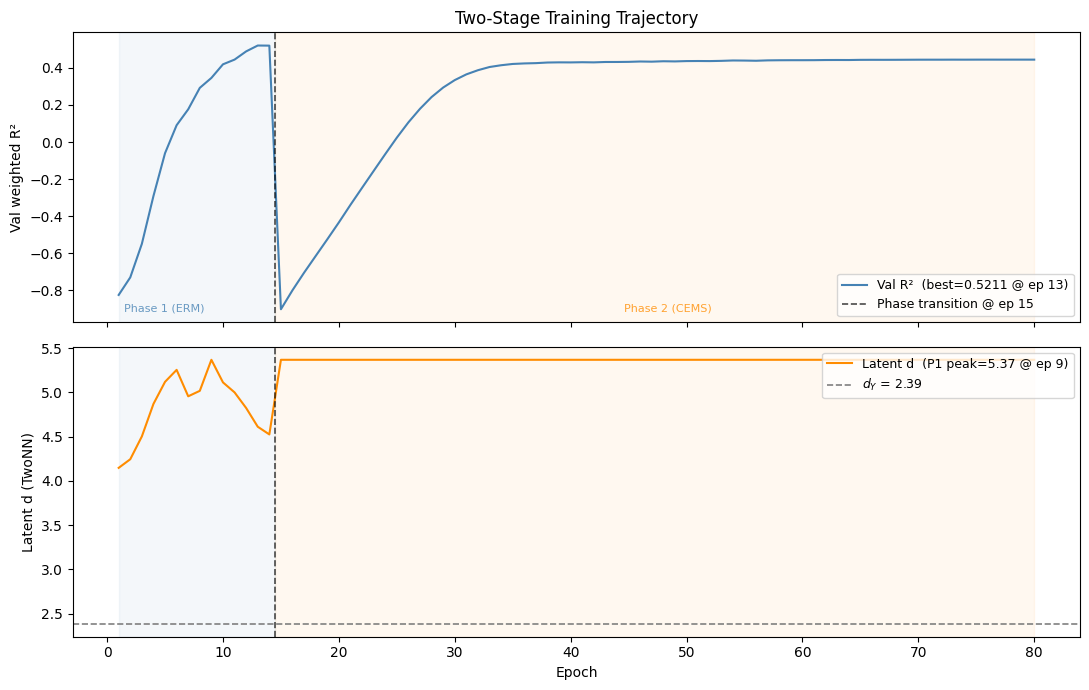

Plot saved to: /kaggle/working/two_stage_trajectory.png

--- Two-stage training summary ---
  Phase 1 : 14 epochs  |  best d = 5.37  @ ep 9
  Phase 2 : 66 epochs  |  best val R² = 0.4449  @ ep 76
  Final   : encoder from ep 9  |  head from ep 76
  d_Y ref = 2.39  |  phase-2 d (frozen) = 5.37


In [ ]:
import matplotlib.pyplot as plt

D_Y = 2.39  # label intrinsic dimension (Part 1 estimate)

epochs_axis   = list(range(1, len(history["val_r2"]) + 1))
val_r2_traj   = history["val_r2"]
latent_d_traj = history["latent_d"]

# Phase 1 statistics
p1_d_vals    = latent_d_traj[:phase1_end_epoch]
peak_d_epoch = int(np.argmax(p1_d_vals)) + 1
peak_d_val   = max(p1_d_vals)

# Overall best val R²
best_r2_epoch = int(np.argmax(val_r2_traj)) + 1
best_r2_val   = max(val_r2_traj)

# Vertical line between last phase-1 and first phase-2 epoch
trans_x = phase_transition_epoch - 0.5

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# ── Top panel: val R² ─────────────────────────────────────
ax1.axvspan(1, trans_x,          alpha=0.06, color="steelblue")
ax1.axvspan(trans_x, epochs_axis[-1], alpha=0.06, color="darkorange")
ax1.plot(epochs_axis, val_r2_traj, color="steelblue", linewidth=1.5,
         label=f"Val R²  (best={best_r2_val:.4f} @ ep {best_r2_epoch})")
ax1.axvline(trans_x, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
            label=f"Phase transition @ ep {phase_transition_epoch}")
ax1.set_ylabel("Val weighted R²")
ax1.set_title("Two-Stage Training Trajectory")
ax1.legend(loc="lower right", fontsize=9)
# Phase labels using axis-fraction coordinates (avoids ylim race)
ax1.text(trans_x / 2 / epochs_axis[-1], 0.03, "Phase 1 (ERM)",
         transform=ax1.transAxes, ha="center", va="bottom", fontsize=8,
         color="steelblue", alpha=0.8)
ax1.text((trans_x + epochs_axis[-1]) / 2 / epochs_axis[-1], 0.03, "Phase 2 (CEMS)",
         transform=ax1.transAxes, ha="center", va="bottom", fontsize=8,
         color="darkorange", alpha=0.8)

# ── Bottom panel: latent d ────────────────────────────────
ax2.axvspan(1, trans_x,          alpha=0.06, color="steelblue")
ax2.axvspan(trans_x, epochs_axis[-1], alpha=0.06, color="darkorange")
ax2.plot(epochs_axis, latent_d_traj, color="darkorange", linewidth=1.5,
         label=f"Latent d  (P1 peak={peak_d_val:.2f} @ ep {peak_d_epoch})")
ax2.axhline(D_Y, color="gray", linestyle="--", linewidth=1.2, label=f"$d_Y$ = {D_Y}")
ax2.axvline(trans_x, color="black", linestyle="--", linewidth=1.2, alpha=0.7)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Latent d (TwoNN)")
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

print("\n--- Two-stage training summary ---")
print(f"  Phase 1 : {phase1_end_epoch} epochs  |  best d = {best_d:.2f}  @ ep {best_d_epoch}")
print(f"  Phase 2 : {remaining_epochs} epochs  |  best val R² = {best_val_r2_p2:.4f}  @ ep {best_val_r2_epoch_p2}")
print(f"  Final   : encoder from ep {best_d_epoch}  |  head from ep {best_val_r2_epoch_p2}")
print(f"  d_Y ref = {D_Y}  |  phase-2 d (frozen) = {phase2_d_ref:.2f}")

## 15. Final Validation Metrics
Evaluate best checkpoint; flag if weighted R² < 0.75 (possible extraction mismatch).

In [15]:
# Final assembled model: frozen encoder (model.encoder) + best head
# Both already loaded with best checkpoints at end of code-13.
model.encoder.eval()
head.eval()

with torch.no_grad():
    val_lats  = model.encoder(torch.tensor(X_val, dtype=torch.float32, device=device))
    val_preds = head(val_lats).cpu().numpy()

val_r2_best   = weighted_global_r2(Y_val_raw, val_preds)
val_rmse_best = rmse_per_target(Y_val_raw, val_preds)

print("=" * 55)
print(f"Final val weighted R²: {val_r2_best:.4f}")
print(f"  encoder from ep {best_d_epoch}  |  head from ep {best_val_r2_epoch_p2}")
print("=" * 55)
print("RMSE per target:")
for t, v in val_rmse_best.items():
    print(f"  {t:<18}: {v:.4f}")
print("=" * 55)

if val_r2_best < 0.75:
    print(
        "\n  *** WARNING: val R² = {:.4f} is significantly below the local baseline"
        " (~0.80).\n"
        "      Likely causes:\n"
        "      1. Feature extraction mismatch (DINOv2 version / resize / normalisation).\n"
        "      2. Random seed / split divergence.\n"
        "      3. Kaggle environment difference (torch/transformers version)."
        .format(val_r2_best)
    )
else:
    print(f"\n  R² = {val_r2_best:.4f} — consistent with local baseline (~0.80). OK.")

Final val weighted R²: 0.4449
  encoder from ep 9  |  head from ep 76
RMSE per target:
  Dry_Green_g       : 23.1364
  Dry_Dead_g        : 10.7878
  Dry_Clover_g      : 12.2013
  GDM_g             : 23.4597
  Dry_Total_g       : 22.4386

  *** WARNING: val R² = 0.4449 is significantly below the local baseline (~0.80).
      Likely causes:
      1. Feature extraction mismatch (DINOv2 version / resize / normalisation).
      2. Random seed / split divergence.
      3. Kaggle environment difference (torch/transformers version).


## 16. Test Inference
Load best checkpoint, encode test features through encoder+head, inverse-scale predictions.

In [16]:
# Final assembled model: frozen encoder + best phase-2 head
model.encoder.eval()
head.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    test_latents = model.encoder(X_test_t)
    test_preds   = head(test_latents).cpu().numpy()

test_preds = np.clip(test_preds, 0.0, None)  # biomass cannot be negative

print(f"test_preds shape: {test_preds.shape}")
print(f"test_preds range: [{test_preds.min():.2f}, {test_preds.max():.2f}]")
print("Sample predictions (first 3 test images):")
for i in range(min(3, len(test_image_ids))):
    print(f"  {test_image_ids[i]}: {dict(zip(TARGETS, test_preds[i].round(2)))}")

test_preds shape: (1, 5)
test_preds range: [1.00, 52.66]
Sample predictions (first 3 test images):
  ID1001187975: {'Dry_Green_g': np.float32(28.4), 'Dry_Dead_g': np.float32(11.54), 'Dry_Clover_g': np.float32(1.0), 'GDM_g': np.float32(33.91), 'Dry_Total_g': np.float32(52.66)}


## 17. Format Predictions as Submission CSV
Map (image_id, 5 targets) → long-format rows matching test.csv sample_id keys.

In [17]:
def prepare_submission(test_csv_path, predictions, image_ids):
    """Returns long-format DataFrame with columns [sample_id, target]."""
    df_t = pd.read_csv(test_csv_path)

    pred_dict = {
        img_id: {col: float(val) for col, val in zip(TARGETS, pred_row)}
        for img_id, pred_row in zip(image_ids, predictions)
    }

    def _get_pred(row):
        img_id      = row["sample_id"].split("__")[0]
        target_name = row["target_name"]
        val = pred_dict.get(img_id, {}).get(target_name, 0.0)
        return max(0.0, val)

    df_t["target"] = df_t.apply(_get_pred, axis=1)
    return df_t[["sample_id", "target"]]


submission = prepare_submission(TEST_CSV, test_preds, test_image_ids)

out_path = os.path.join(cfg.output_dir, "submission.csv")
submission.to_csv(out_path, index=False)

print(f"Submission saved to: {out_path}")
print(f"Rows: {len(submission)}")
print(submission.head(10))
print("\nTarget value stats:")
print(submission["target"].describe().round(3))
print("\nWorking dir:", os.listdir(cfg.output_dir))

Submission saved to: /kaggle/working/submission.csv
Rows: 5
                    sample_id     target
0  ID1001187975__Dry_Clover_g   0.996477
1    ID1001187975__Dry_Dead_g  11.537954
2   ID1001187975__Dry_Green_g  28.398699
3   ID1001187975__Dry_Total_g  52.660595
4         ID1001187975__GDM_g  33.906761

Target value stats:
count     5.000
mean     25.500
std      20.076
min       0.996
25%      11.538
50%      28.399
75%      33.907
max      52.661
Name: target, dtype: float64

Working dir: ['two_stage_trajectory.png', '.virtual_documents', 'submission.csv']
